# Use computed velocity field

MARTHE can compute groundwater flow velocity field.
The output file is write as a column separated text file and **not** as a
Marthe grid file.
Therefore, a specific function is provided to read such output.

In [1]:
# load package and read data
import gridmarthe as gm
ds = gm.read_velocity('data/veloci.out')

The read data store different velocity variables: `vx` (velocity along x dimension),
`vy`, `vz`, `vmod` (the velocity module), etc.

In [2]:
print(ds)

<xarray.Dataset> Size: 89kB
Dimensions:  (istep: 1, zone: 927)
Coordinates:
  * istep    (istep) int64 8B 6210
  * zone     (zone) int64 7kB 1 2 3 4 5 6 7 8 ... 921 922 923 924 925 926 927
    time     (istep) float64 8B 6.422e+03
Data variables:
    vx       (istep, zone) float64 7kB 0.0 0.0 0.0 ... 8.64e-07 -4.219e-07
    vy       (istep, zone) float64 7kB 0.0 -1.945e-06 ... -1.552e-06 -3.589e-07
    vz       (istep, zone) float64 7kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    vmod     (istep, zone) float64 7kB 0.0 1.945e-06 ... 1.776e-06 5.539e-07
    x        (zone) float64 7kB 617.8 618.2 618.8 619.2 ... 606.8 607.2 607.8
    y        (zone) float64 7kB 2.567e+03 2.567e+03 ... 2.543e+03 2.543e+03
    z        (zone) float64 7kB 115.6 114.8 111.1 110.4 ... 11.57 11.4 10.8 11.0
    igrid    (zone) int64 7kB 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    lay      (zone) int64 7kB 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    row      (zone) int64 7kB 5 5 5 5 5 5 5 6 6

A specific function can be used to plot the velocity field with matplotlib
quiver plot.
The velocity is normed for visualisation convenience.

/mnt/d/home/gridmarthe/src/gridmarthe/plot.py:344: RuntimeWarning: invalid value encountered in divide
  vx_norm = vx / norm
/mnt/d/home/gridmarthe/src/gridmarthe/plot.py:345: RuntimeWarning: invalid value encountered in divide
  vy_norm = vy / norm


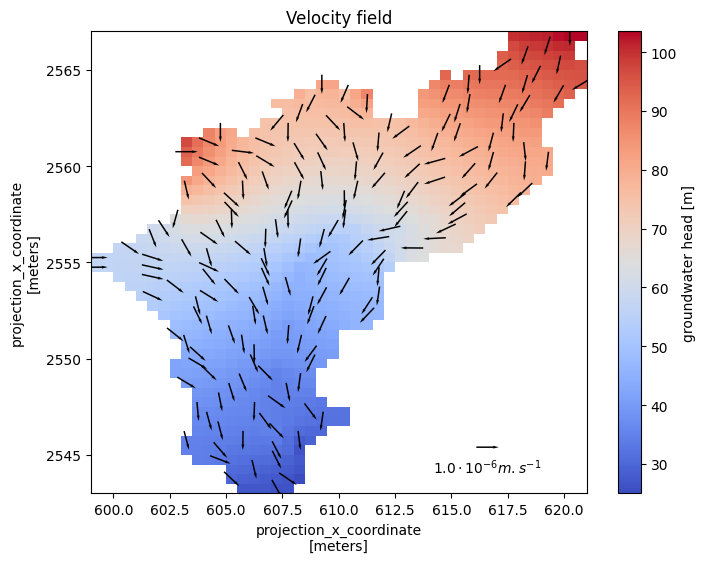

In [3]:
import matplotlib.pyplot as plt

# read groundwater head for visualisation
headsim = gm.load_marthe_grid('data/chasim_hallue.out', fpastp='./data/hallue.pastp', drop_nan=True)
headsim2d = gm.assign_coords(headsim.isel(time=-1))

# plot it with velocity field
fig, ax = plt.subplots(figsize=(8, 6))
headsim2d['charge'].plot(ax=ax, cmap='coolwarm')
gm.plot_veloc_quiver(ds, ax=ax, xyfreq=5, loc_scale_xy=(0.8,0.1))
plt.show()